## Sequence-to-Sequence Model for Machine Translation

In this assignment we will apply transformer-based model for machine translation.

We will use tools from `transformers`, `datasets` and `evaluate` libraries by HuggingFace.




In [ ]:
!pip install datasets evaluate transformers[sentencepiece]
!pip install accelerate

In [ ]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
print(device)

cuda


### Data


Today there's a number of pretrained machine translation models for different languages. But in practice we could face a task of domain specific translation where general pretrained models sometimes fail to show good performance.

Let's try to fine-tune pretrained machine translation model on medical data. We will use PubMed dataset with English-French texts from `datasets` library.

In [ ]:
from datasets import load_dataset

raw_datasets = load_dataset("qanastek/WMT-16-PubMed", lang1="en", lang2="fr")

In [ ]:
raw_datasets

DatasetDict({
    train: Dataset({
        features: ['translation'],
        num_rows: 614093
    })
})

We will split the dataset into train and validation part.

In [ ]:
split_datasets = raw_datasets["train"].train_test_split(train_size=0.8, seed=20)
split_datasets

DatasetDict({
    train: Dataset({
        features: ['translation'],
        num_rows: 491274
    })
    test: Dataset({
        features: ['translation'],
        num_rows: 122819
    })
})

In [ ]:
split_datasets["validation"] = split_datasets.pop("test")

In [ ]:
split_datasets

DatasetDict({
    train: Dataset({
        features: ['translation'],
        num_rows: 491274
    })
    validation: Dataset({
        features: ['translation'],
        num_rows: 122819
    })
})

### Tokenization

We will use transformer model `Helsinki-NLP/opus-mt-en-fr` pretrained for machine translation from English to French.

Transformer models use BPE tokenization and tokenizer is trained simultaneously with model training. So we need to load tokenizer from the pretrained model we are going to apply.

In [ ]:
from transformers import AutoTokenizer

model_checkpoint = "Helsinki-NLP/opus-mt-en-fr"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint, return_tensors="pt")

Check the results of tokenization for some examples in English and in French.

In [ ]:
text = 'Hyponatremia in the elderly: its role in the frailty'
tokenized = tokenizer(text)
tokenized

{'input_ids': [36619, 10484, 158, 27621, 18, 4, 13931, 37, 96, 908, 18, 4, 1231, 17465, 1744, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}

To get tokens from the ids returned by tokenizer, we can use `convert_ids_to_tokens`.

In [ ]:
print(tokenizer.convert_ids_to_tokens(tokenized['input_ids']))

['▁Hypo', 'nat', 're', 'mia', '▁in', '▁the', '▁elderly', ':', '▁its', '▁role', '▁in', '▁the', '▁f', 'rail', 'ty', '</s>']


In [ ]:
text = "L'hyponatrémie du sujet âgé: implication dans la fragilité"
tokenized = tokenizer(text)

In [ ]:
print(tokenizer.convert_ids_to_tokens(tokenized['input_ids']))

['▁L', "'", 'hy', 'pon', 'at', 'ré', 'mie', '▁du', '▁su', 'jet', '▁â', 'gé', ':', '▁implication', '▁dans', '▁la', '▁fra', 'g', 'il', 'ité', '</s>']


Note that French text was split into very short tokens as the tokenizer didn't recognize the target language. To tokenize target text correctly we need to pass it with the argument `text_target`.

In [ ]:
text = "L'hyponatrémie du sujet âgé: implication dans la fragilité"
tokenized = tokenizer(text_target=text)

In [ ]:
print(tokenizer.convert_ids_to_tokens(tokenized['input_ids']))

['▁L', "'", 'hypo', 'nat', 'r', 'émie', '▁du', '▁sujet', '▁âgé', ':', '▁implication', '▁dans', '▁la', '▁fragilité', '</s>']


Now we will write a function to preprocess dataset items using tokenizer.

We want to set maximum length for the texts and cut all the texts that appear to be longer. So we will apply a tokenizer with fixed maximum sequence length using `max_length` parameter and setting `truncation=True`.

Let us first investigate datasets

In [ ]:
split_datasets

DatasetDict({
    train: Dataset({
        features: ['translation'],
        num_rows: 491274
    })
    validation: Dataset({
        features: ['translation'],
        num_rows: 122819
    })
})

**Task 1**

Let's find the longest texts in our dataset.

Write a function that gets dataset as input and returns the maximum length of the examples in dataset and its index. For now, let's just cound the number of characters as len.

In [ ]:
def find_idx_of_max_len(dataset):
    max_len = 0
    idx_of_max_len = 0
    for idx, el in enumerate(dataset):
        cur_len = len(el['translation']['en'])
        if cur_len > max_len:
            max_len = cur_len
            idx_of_max_len = idx
    return max_len, idx_of_max_len

In [ ]:
find_idx_of_max_len(split_datasets['train'])

(479, 421679)

In [ ]:
find_idx_of_max_len(split_datasets['validation'])

(457, 40891)

Now let us see what length will be for the encoded sentences

In [ ]:
split_datasets['train'][421679]['translation']['en']

'Double epidemic of Bornholm disease and infectious hepatitis in the Mulhouse region (epidemiology, symptomatology, pathological anatomy and antibiotic therapy); their epidemiological connection with poliomyelitis, infectious mononucleosis and homologous serum jaundice in the same area (southern half of the Department du Haut-Rhin.) II. Discussion of the etiology, pathogenic and symptomatic peculiarities, anatomo-pathological characteristics and therapy of the presented cases'

In [ ]:
len(tokenizer(split_datasets['train'][421679]['translation']['en'])['input_ids'])

102

In [ ]:
split_datasets['train'][421679]['translation']['fr']

"Epidémies jumelées de maladie de Bornholm et d'ictère épidémique dans la région mulhousienne (épidémiologie, symptomatologie, anatomie pathologique, thérapeutique par les antibiotiques); leurs rapports épidémiologiques avec la poliomyélite, la mononucléose infectieuse et l'ictére d'inoculation dans cette même contrée (moitié Sud du Département du Haut-Rhin). II. Discussion de l'etiologie, des particularites pathogeniques et symptomatiques, des caracteristiques anatomo-pathologiques et therapeutiques des cas exposes"

In [ ]:
len(tokenizer(text_target=split_datasets['train'][421679]['translation']['fr'])['input_ids'])

140

So we can see that for translation the amount of tokens is higher.

So let us use `128` for `max_len`

In [ ]:
tokenizer([el['en'] for el in split_datasets['train'][0:5]['translation']])

{'input_ids': [[47, 3790, 2468, 49, 19073, 6732, 40086, 7, 4, 1684, 2803, 33150, 0], [89, 8283, 14650, 1510, 37782, 751, 4648, 34357, 4354, 2540, 25291, 23496, 2735, 3010, 0], [15093, 3994, 14800, 37, 15, 528, 292, 42, 15, 19370, 12149, 2844, 0], [25101, 7, 171, 239, 21, 9890, 12451, 6955, 263, 24395, 2597, 0], [436, 2754, 6673, 687, 1071, 3791, 4268, 27551, 9, 42, 5110, 806, 3791, 3509, 9, 10, 1447, 19117, 157, 27742, 253, 329, 2636, 2252, 18, 5887, 0]], 'attention_mask': [[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]]}

And, funally, let us implement the preprocessing function:

In [ ]:
# examples -- dataset items
def preprocess_function(batch, max_len = 128):
    #print(batch)
    tokenized_en = tokenizer([el['en'] for el in batch['translation']],
                             max_length=max_len,
                             truncation=True,
                             )
    tokenized_fr = tokenizer(text_target=[el['fr'] for el in batch['translation']],
                             max_length=max_len,
                             truncation=True,
                             )

    ans = []
    INPUT_IDS = 'input_ids'
    LABELS = 'labels'
    ATTENTION_MASK = 'attention_mask'


    n = len(tokenized_en[INPUT_IDS])


    ans =  {INPUT_IDS : [tokenized_en[INPUT_IDS][idx] for idx in range(n)],
              ATTENTION_MASK : [tokenized_en[ATTENTION_MASK][idx] for idx in range(n)],
             LABELS : [tokenized_fr[INPUT_IDS][idx] for idx in range(n)]
            }


    return ans


Create tokenized dataset by appling preprocessing function to `split_datasets` with `map` method. Set parameter `batched=True` to make computing faster.

In [ ]:
tokenized_datasets = split_datasets.map(preprocess_function, batched=True)

Map:   0%|          | 0/491274 [00:00<?, ? examples/s]

Map:   0%|          | 0/122819 [00:00<?, ? examples/s]

Now let us see on our preprocessed dataset

In [ ]:
tokenized_datasets['train'][0]

{'translation': {'en': 'Isolated glomus tumor of the left lower limb',
  'fr': 'Tumeur glomique isolée du membre inférieur gauche'},
 'input_ids': [47,
  3790,
  2468,
  49,
  19073,
  6732,
  40086,
  7,
  4,
  1684,
  2803,
  33150,
  0],
 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
 'labels': [491, 19219, 954, 376, 24087, 33692, 22, 1084, 6792, 4789, 0]}

### Model

We can use the model for inference with the help of pipeline from `transformers` library. To initialize pipeline we need to pass task type (in our case `translation`) and model name.

In [ ]:
from transformers import pipeline

model_checkpoint = "Helsinki-NLP/opus-mt-en-fr"
translator = pipeline("translation", model=model_checkpoint)


Take a look at some examples of translation by pretrained model.

In [ ]:
translator("Clinical efficacy of eculizumab as treatment of gemcitabine-induced thrombotic microangiopathy: A case report")
# Efficacité de l'éculizumab comme traitement de la microangiopathie thrombotique induite par la gemcitabine : à propos d'un cas

[{'translation_text': "Efficacité clinique de l'eculizumab comme traitement de la microangiopathie thrombotique induite par la gemcitabine: rapport de cas"}]

In [ ]:
translator("Proliferative verrucous leukoplakia: Three cases and literature review")
# Leucoplasie verruqueuse proliférative : trois observations et revue de la littérature

[{'translation_text': 'Verrucous leukoplakia proliférative : trois cas et revue de la littérature'}]

To fine-tune the model on our data we need to load it from pretrained checkpoint.

`transformers` library offers wide range of the models for various tasks (for example, `AutoModelForSequenceClassification`, `AutoModelForTokenClassification`, `AutoModelWithLMHead`). For the task of machine translation we will use `AutoModelForSeq2SeqLM` model.

In [ ]:
from transformers import AutoModelForSeq2SeqLM
model = AutoModelForSeq2SeqLM.from_pretrained(model_checkpoint)

Take a look at the model's structure.

In [ ]:
model.model.encoder.layers[0].self_attn.num_heads

8

In [ ]:
model

MarianMTModel(
  (model): MarianModel(
    (shared): Embedding(59514, 512, padding_idx=59513)
    (encoder): MarianEncoder(
      (embed_tokens): Embedding(59514, 512, padding_idx=59513)
      (embed_positions): MarianSinusoidalPositionalEmbedding(512, 512)
      (layers): ModuleList(
        (0-5): 6 x MarianEncoderLayer(
          (self_attn): MarianAttention(
            (k_proj): Linear(in_features=512, out_features=512, bias=True)
            (v_proj): Linear(in_features=512, out_features=512, bias=True)
            (q_proj): Linear(in_features=512, out_features=512, bias=True)
            (out_proj): Linear(in_features=512, out_features=512, bias=True)
          )
          (self_attn_layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (activation_fn): SiLUActivation()
          (fc1): Linear(in_features=512, out_features=2048, bias=True)
          (fc2): Linear(in_features=2048, out_features=512, bias=True)
          (final_layer_norm): LayerNorm((512,),

### Self-Attention

Let's get a closer look at the internals of transformer models.

Transformer models are based on self-attention mechanism.
An attention function aims to assess the relation between the elements of the sequence. The output for each element is computed as a weighted sum of the value vectors of other elements, where the weight for each value is computed by a score function for the query vector (for current element) with the corresponding key (for key-value pairs of other elements). Query, key and value vectors are computed multiplying embeddings by weight matrices $W_q$, $W_k$, $W_v$ that are trained during the model training.

$$                                                                         
   \mathrm{Attention}(Q, K, V) = \mathrm{softmax}(\frac{QK^T}{\sqrt{d_k}})V               
$$


We will now implement self-attention mechanism. That's what we'll do:

1. Create random embedding tensor $X$ of dimension $[sequence\_length, emb\_dim]$, where $emb\_dim$ is the dimension of embedding layer in the pretrained model.
2. In `SelfAttention` class implement method `initialize_weights` to create random tensors of weights for queries, keys and values $w_q$, $w_k$, $w_v$ of dimension $[emb\_dim, dim_k]$ (dimension of query, key and value vector will be equal, let's set $dim_k = 64$).
3. In `SelfAttention` class implement method `forward` to calculate dot-product attention. The method should take embedding tensor $X$ as an input.
 - Compute $query$, $key$ and $value$ tensors multiplying embeddings by weights $w_q$, $w_k$, $w_v$ (the result tensors should have dimension $[sequence\_length, dim_k]$).
 - Take the dot product of the queries with keys.
 - Divide the obtaned result by the dimension of key vector.
 - Apply softmax to get the scores for the values.

                                                                                     
                                                                 


In [ ]:
import torch.nn as nn
import numpy as np
import torch.nn.functional as F

We write function taking in mind batch_dimension. But also our function will work without batch dimension

**Task 2**
Fill in the gaps in SelfAttention Class

In [ ]:
class SelfAttention(nn.Module):
  def __init__(self, seq_len, emb_dim, dim_k):
    super(SelfAttention, self).__init__()
    self.emb_dim = emb_dim
    self.seq_len = seq_len
    self.dim_k = dim_k
    self.initialize_weights()

  def initialize_weights(self):
    self.w_q = nn.Linear(self.emb_dim, self.dim_k, bias=False) # Initialize matrix W_q as nn.Linear layer. Don't forget to set bias=False
    self.w_k = nn.Linear(self.emb_dim, self.dim_k, bias=False) # Initialize matrix W_k as nn.Linear layer. Don't forget to set bias=False
    self.w_v = nn.Linear(self.emb_dim, self.dim_k, bias=False) # Initialize matrix W_v as nn.Linear layer. Don't forget to set bias=False

  def forward(self, X):
    # X [b, l, emb]

    # [b, l, dk]
    query = self.w_q(X) # Apply W_q matrix to X

    # [b, l, dk]
    key = self.w_k(X) # Apply W_k matrix to X

    # [k, l, dk]
    value = self.w_v(X) # Apply W_v matrix to X


    # [b, l, l]
    prod = query.matmul(key.transpose(-1,-2)) # dot product

    # [b, l, l]
    prod = prod / np.sqrt(self.dim_k) # Normalize the result by the dimension of a key vector

    #  [b, l, l]
    prod = F.softmax(prod, dim = -1) # Apply SoftMax to prod (think which dim you need to apply it on)

    # since we need only weights we dont multiply on values
    attn_weights = prod
    attn_vector = prod.unsqueeze(-2).matmul(value.unsqueeze(-3)).squeeze(-2) # [b, l, 1, l] matmul [b, 1, l, dk] = [b, l, 1, dk] -> [b, l, dk]

    return attn_weights, attn_vector

In [ ]:
# create embedding tensor X
X = torch.randn([1, 10, 512]) # 1 is dimension for batch

In [ ]:
# initialize SelfAttention layer
self_attention = SelfAttention(seq_len=10, emb_dim=512, dim_k=64)

In [ ]:
# calculate attention weights for X
attn_weights = self_attention(X)

In [ ]:
attn_weights.shape

torch.Size([1, 10, 10])

But also we can see that our module works without batch dimension

In [ ]:
X = torch.randn([10, 512]) # without batch dimension
self_attention(X).shape

torch.Size([10, 10])

### Attention Weights

Now let's check out attention weights of our pretrained model.

To access the attention weights we can run `generate` method using parameters `return_dict_in_generate` and `output_attentions`. Let's set `num_beams=1` and `do_sample=False` to apply simple greedy search decoding.

In [ ]:
input_text = "Proliferative verrucous leukoplakia: Three cases and literature review"
input_ids = tokenizer.encode(input_text, return_tensors='pt')  # tokenize input text
outputs = model.generate(input_ids, return_dict_in_generate=True, output_attentions=True, num_beams=1, do_sample=False)


/home/m/anaconda3/envs/env_gen_ai_sem_0006/lib/python3.11/site-packages/transformers/generation/utils.py:1369: UserWarning: Using `max_length`'s default (512) to control the generation length. This behaviour is deprecated and will be removed from the config in v5 of Transformers -- we recommend using `max_new_tokens` to control the maximum length of the generation.
  warnings.warn(


`generate` methods returns dict with predicted tokens, and attention values including encoder, decoder and encoder-decoder attention weights.

In [ ]:
outputs.keys()

odict_keys(['sequences', 'encoder_attentions', 'decoder_attentions', 'cross_attentions'])

Let's look into cross attentions to get the idea how input tokens affect each of the predicted tokens.

Each element of `cross_attentions` object contains attention weights for a single generated token. Attention weights for each generated token have tensors of weights for each decoder layer. Attention weights tensor for a single layer has a shape [batch size, number of attention heads, generated sequence length, input sequence length]. As the tensor corresponds to a single generated token, generated sequence length equals 1.

In [ ]:
input_ids.shape

torch.Size([1, 21])

In [ ]:
outputs['sequences'].shape

torch.Size([1, 25])

In [ ]:
# one element for each generated token
len(outputs['cross_attentions'])

24

In [ ]:
# one element for each layer of the decoder
len(outputs['cross_attentions'][0])

6

In [ ]:
# batch_size, num_heads, generated_length, sequence_length
outputs['cross_attentions'][0][0].size()

torch.Size([1, 8, 1, 21])

**Task 3**

Here we will write code to build a tensor of cross-attention weights with size `[generated_length, input_sequence]` for a fixed attention head and fixed decoder layer (let's take last layer).

In [ ]:
# input_ids -- tensor of input tokens ids
# outputs -- output of generate method
# attn_head_id -- number of attention head
# decoder_layer_id -- number of decoder layer

import torch

def build_attn(input_ids, outputs, attn_head_id, decoder_layer_id):
    gen_len = outputs['sequences'].shape[-1] - 1 # -1 since we don't see on eos in generated
    input_len = input_ids.shape[-1]
    ans = []
    for idx_gen in range(gen_len):
      ans.append(outputs['cross_attentions'][idx_gen][decoder_layer_id][0][attn_head_id])

    attn_tensor = torch.cat(ans, dim=0)
    return attn_tensor

Visualize this tensor of cross-attention weights using heatmap to see the relation between input and output tokens.

Try the visualization for different input texts and analyze the results.

In [ ]:
attn_weights = build_attn(input_ids, outputs, 0, -1)
attn_weights.shape

torch.Size([24, 21])

In [ ]:
attn_weights[-1]

tensor([0.0730, 0.0525, 0.0765, 0.0789, 0.0387, 0.0524, 0.0364, 0.0672, 0.0278,
        0.0219, 0.0169, 0.0250, 0.0132, 0.0233, 0.0602, 0.0247, 0.0389, 0.0663,
        0.0766, 0.0501, 0.0795])

Next we use function for attention visualization from seminar


In [ ]:
outputs['sequences'].shape

torch.Size([1, 25])

In [ ]:
input_ids.shape

torch.Size([1, 21])

In [ ]:
import matplotlib.pyplot as plt
# plt.switch_backend('agg')
import matplotlib.ticker as ticker

In [ ]:
def showAttention(input_ids, outputs, attn_head_id=0, decoder_layer_id=-1):
    # Set up figure with colorbar

    attentions = build_attn(input_ids, outputs, attn_head_id, decoder_layer_id)

    fig = plt.figure()
    ax = fig.add_subplot(111)
    cax = ax.matshow(attentions.numpy(), cmap='bone')
    fig.colorbar(cax)

    input_sentence = list(tokenizer.convert_ids_to_tokens(input_ids[0]))[:-1] # drop EOS token
    output_sentence = list(tokenizer.convert_ids_to_tokens(outputs['sequences'][0]))[:-1] # drop EOS token

    # Set up axes
    ax.set_xticklabels([''] + list(input_sentence)
                       +['<EOS>'],
                       rotation=90)
    ax.set_yticklabels([''] + output_sentence)

    # Show label at every tick
    ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(1))

    plt.show()


In [ ]:
input_text = "Proliferative verrucous leukoplakia: Three cases and literature review"
input_ids = tokenizer.encode(input_text, return_tensors='pt')  # tokenize input text
outputs = model.generate(input_ids, return_dict_in_generate=True, output_attentions=True, num_beams=1, do_sample=False)

/home/m/anaconda3/envs/env_gen_ai_sem_0006/lib/python3.11/site-packages/transformers/generation/utils.py:1369: UserWarning: Using `max_length`'s default (512) to control the generation length. This behaviour is deprecated and will be removed from the config in v5 of Transformers -- we recommend using `max_new_tokens` to control the maximum length of the generation.
  warnings.warn(


Let us investigate some examples

/tmp/ipykernel_7025/2487159517.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + list(input_sentence)
/tmp/ipykernel_7025/2487159517.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + output_sentence)


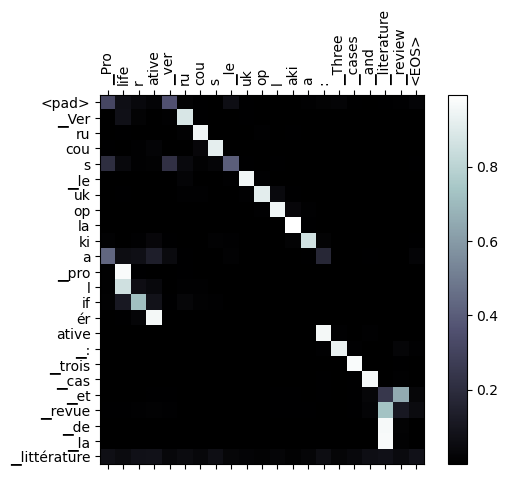

In [ ]:
showAttention(input_ids, outputs)

/tmp/ipykernel_9708/2487159517.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + list(input_sentence)
/tmp/ipykernel_9708/2487159517.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + output_sentence)


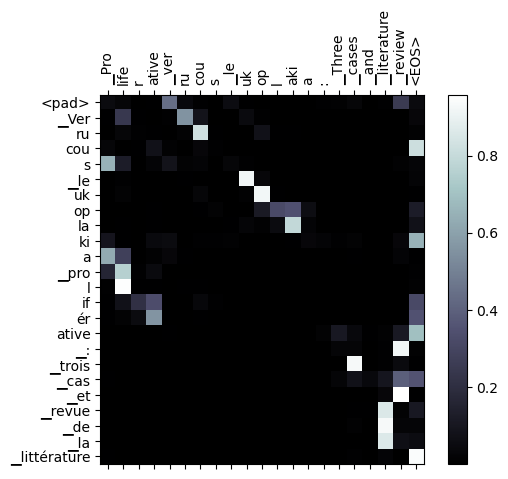

In [ ]:
showAttention(input_ids, outputs, attn_head_id=1)

Next we see on other decoder  heads

/tmp/ipykernel_9708/2487159517.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + list(input_sentence)
/tmp/ipykernel_9708/2487159517.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + output_sentence)


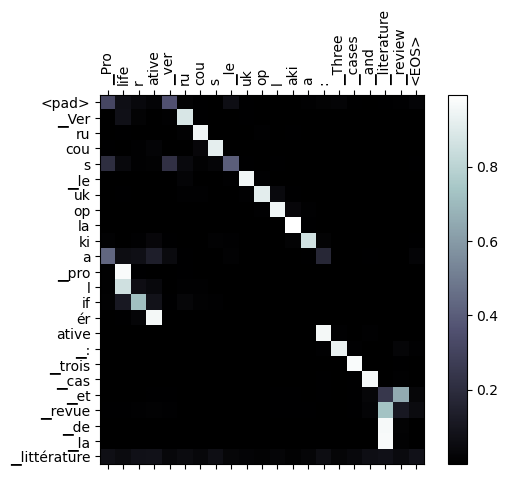

/tmp/ipykernel_9708/2487159517.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + list(input_sentence)
/tmp/ipykernel_9708/2487159517.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + output_sentence)


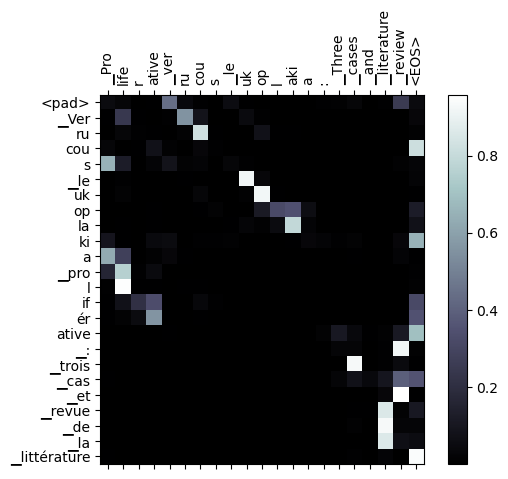

/tmp/ipykernel_9708/2487159517.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + list(input_sentence)
/tmp/ipykernel_9708/2487159517.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + output_sentence)


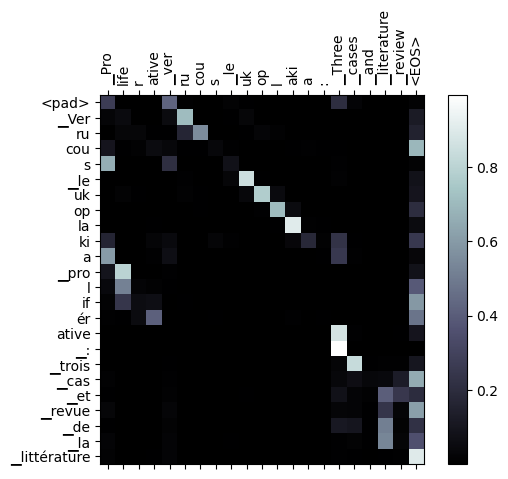

/tmp/ipykernel_9708/2487159517.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + list(input_sentence)
/tmp/ipykernel_9708/2487159517.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + output_sentence)


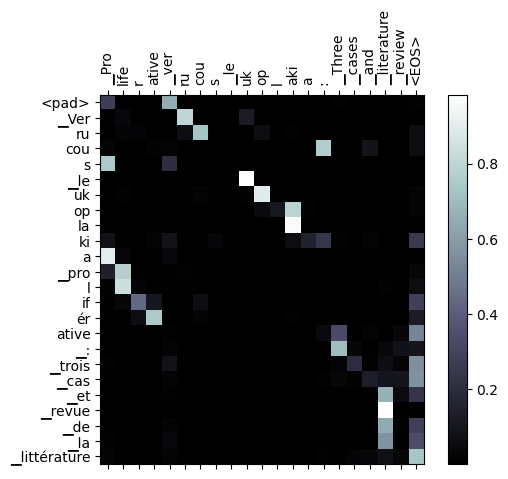

/tmp/ipykernel_9708/2487159517.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + list(input_sentence)
/tmp/ipykernel_9708/2487159517.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + output_sentence)


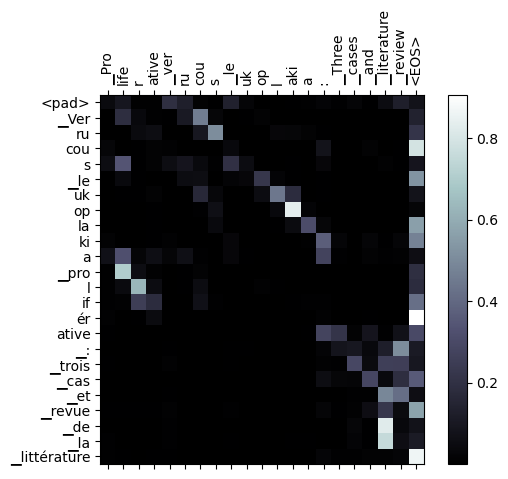

/tmp/ipykernel_9708/2487159517.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + list(input_sentence)
/tmp/ipykernel_9708/2487159517.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + output_sentence)


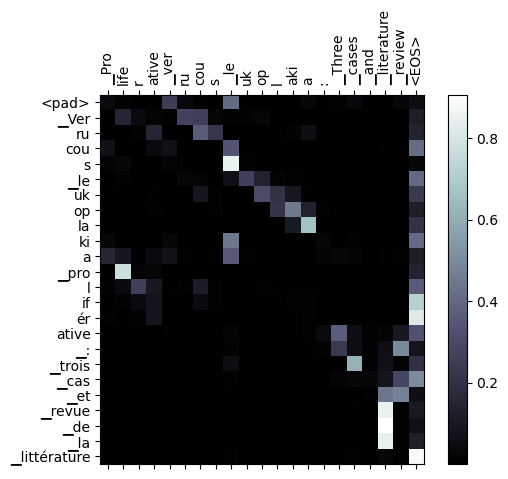

/tmp/ipykernel_9708/2487159517.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + list(input_sentence)
/tmp/ipykernel_9708/2487159517.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + output_sentence)


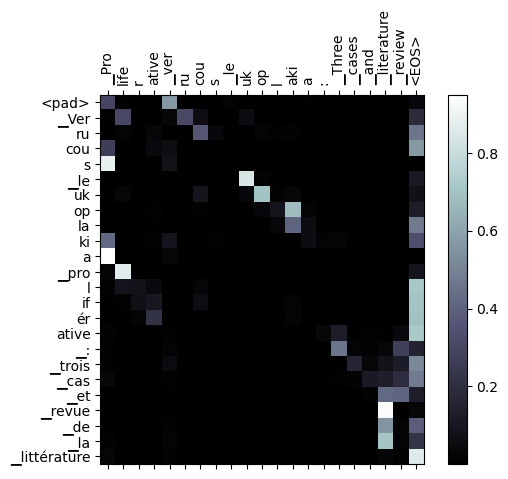

/tmp/ipykernel_9708/2487159517.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + list(input_sentence)
/tmp/ipykernel_9708/2487159517.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + output_sentence)


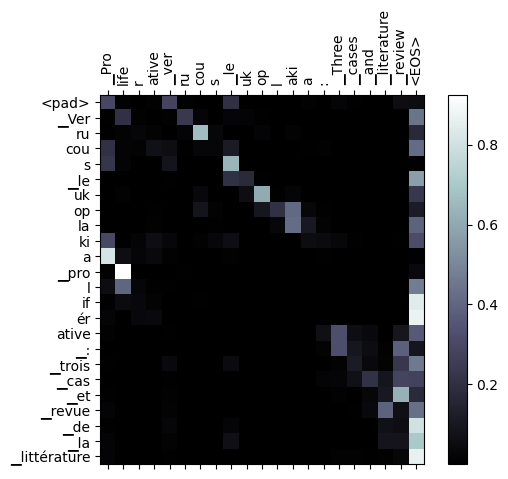

In [ ]:
for attn_head in range(8):
    showAttention(input_ids, outputs, attn_head_id=attn_head)

Let us try another examples

In [ ]:
input_text = "This theorem is amazing"
input_ids = tokenizer.encode(input_text, return_tensors='pt')  # tokenize input text
outputs = model.generate(input_ids, return_dict_in_generate=True, output_attentions=True, num_beams=1, do_sample=False)

/home/m/anaconda3/envs/env_gen_ai_sem_0006/lib/python3.11/site-packages/transformers/generation/utils.py:1369: UserWarning: Using `max_length`'s default (512) to control the generation length. This behaviour is deprecated and will be removed from the config in v5 of Transformers -- we recommend using `max_new_tokens` to control the maximum length of the generation.
  warnings.warn(


/tmp/ipykernel_9708/2487159517.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + list(input_sentence)
/tmp/ipykernel_9708/2487159517.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + output_sentence)


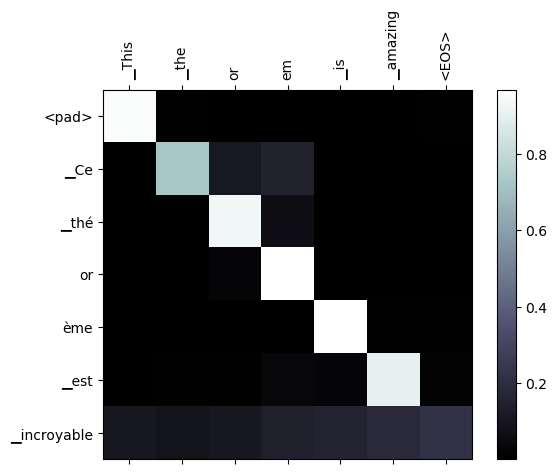

In [ ]:
showAttention(input_ids, outputs)

So we see that the first head 'looks' on one token forward

/tmp/ipykernel_9708/2487159517.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + list(input_sentence)
/tmp/ipykernel_9708/2487159517.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + output_sentence)


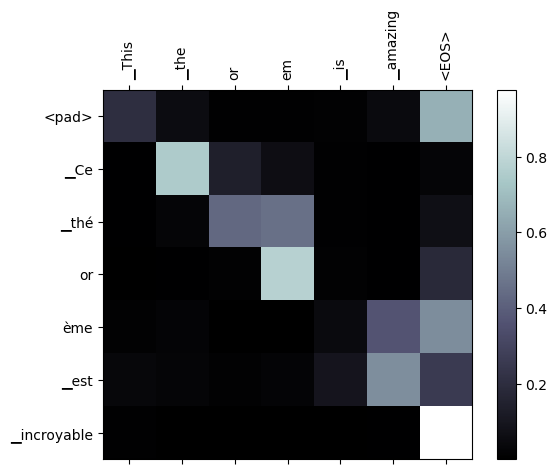

In [ ]:
showAttention(input_ids, outputs, attn_head_id=1)

/tmp/ipykernel_9708/2487159517.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + list(input_sentence)
/tmp/ipykernel_9708/2487159517.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + output_sentence)


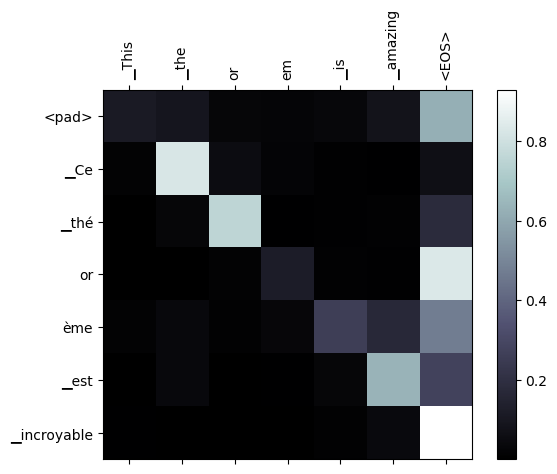

In [ ]:
showAttention(input_ids, outputs, attn_head_id=2)

So it is difficult to say something about the role of this two heads.

In [ ]:
input_text = "I love to study"
input_ids = tokenizer.encode(input_text, return_tensors='pt')  # tokenize input text
outputs = model.generate(input_ids, return_dict_in_generate=True, output_attentions=True, num_beams=1, do_sample=False)

/tmp/ipykernel_9708/2487159517.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + list(input_sentence)
/tmp/ipykernel_9708/2487159517.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + output_sentence)


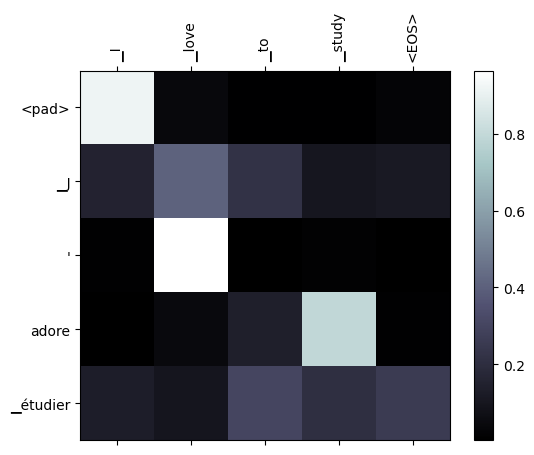

In [ ]:
showAttention(input_ids, outputs, attn_head_id=0)

### Positional Encodings

Now let's take a look at embeddings and positional encodings that are used in transformer models. As we can see from the structure of our pretrained model, it uses sinusoidal position embeddings.

In [ ]:
model

MarianMTModel(
  (model): MarianModel(
    (shared): Embedding(59514, 512, padding_idx=59513)
    (encoder): MarianEncoder(
      (embed_tokens): Embedding(59514, 512, padding_idx=59513)
      (embed_positions): MarianSinusoidalPositionalEmbedding(512, 512)
      (layers): ModuleList(
        (0-5): 6 x MarianEncoderLayer(
          (self_attn): MarianAttention(
            (k_proj): Linear(in_features=512, out_features=512, bias=True)
            (v_proj): Linear(in_features=512, out_features=512, bias=True)
            (q_proj): Linear(in_features=512, out_features=512, bias=True)
            (out_proj): Linear(in_features=512, out_features=512, bias=True)
          )
          (self_attn_layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (activation_fn): SiLUActivation()
          (fc1): Linear(in_features=512, out_features=2048, bias=True)
          (fc2): Linear(in_features=2048, out_features=512, bias=True)
          (final_layer_norm): LayerNorm((512,),

**Task 4.**

Check the encoder embeddings and their shape applying embedding layer to ids of input tokens.

In [ ]:
pos_encoder = model.model.encoder.embed_positions

Get positional encodings applying its layer to the shape of input tensor.

In [ ]:
pos_encodings = pos_encoder(torch.Size([1,256]))

Visualize obtained positional encodings using heatmap.

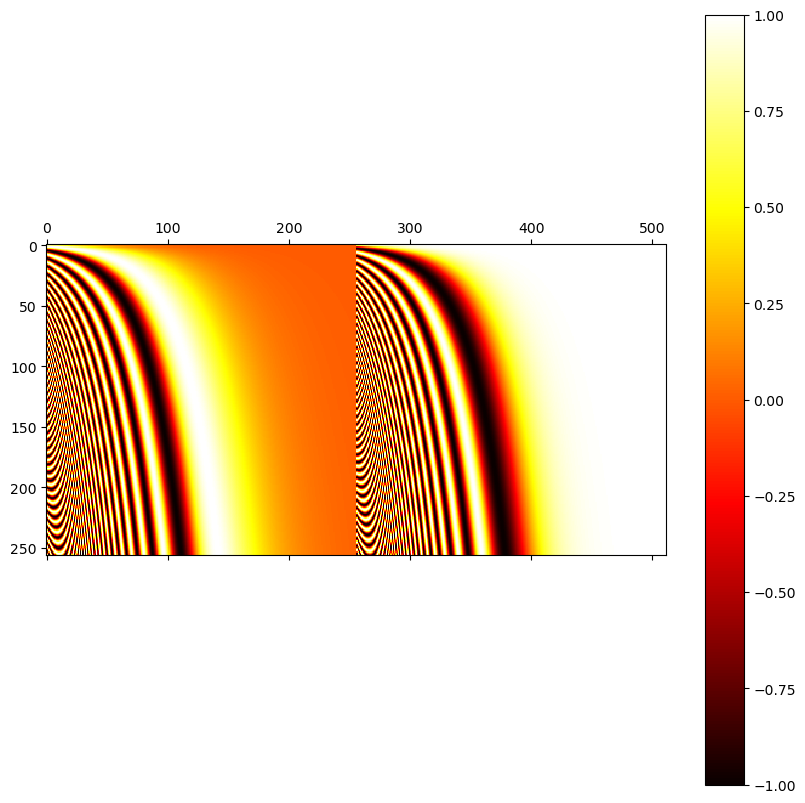

In [ ]:
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111)
cax = ax.matshow(pos_encodings.numpy(), cmap='hot')
fig.colorbar(cax)

### Training

Now we can move on to fine-tuning of the pretrained model on our data. First let's create data collator to form batches with padding to maximum length of sequence within a batch.

In [ ]:
from transformers import DataCollatorForSeq2Seq
data_collator = DataCollatorForSeq2Seq(tokenizer, model=model)

In [ ]:
tokenized_datasets = tokenized_datasets.remove_columns(['translation'])

In [ ]:
batch = data_collator([tokenized_datasets["train"][i] for i in range(0, 3)])
batch.keys()

dict_keys(['input_ids', 'attention_mask', 'labels', 'decoder_input_ids'])

In [ ]:
batch["labels"]

tensor([[  491, 19219,   954,   376, 24087, 33692,    22,  1084,  6792,  4789,
             0,  -100,  -100,  -100,  -100,  -100,  -100,  -100],
        [   89,  8283, 11724,  3368,  2009,  2558,  8605,    87,     6, 11699,
           150,  2558,  7605, 11396, 18113, 23411,  3495,     0],
        [   60, 14800, 15093,  3994,    78,    17,  1833,    20,     6,   112,
          6517,    17,  1612, 13147, 12149,     0,  -100,  -100]])

In [ ]:
batch["decoder_input_ids"]

tensor([[59513,   491, 19219,   954,   376, 24087, 33692,    22,  1084,  6792,
          4789,     0, 59513, 59513, 59513, 59513, 59513, 59513],
        [59513,    89,  8283, 11724,  3368,  2009,  2558,  8605,    87,     6,
         11699,   150,  2558,  7605, 11396, 18113, 23411,  3495],
        [59513,    60, 14800, 15093,  3994,    78,    17,  1833,    20,     6,
           112,  6517,    17,  1612, 13147, 12149,     0, 59513]])

In [ ]:
for i in range(3):
    print(tokenized_datasets["train"][i]["labels"])

[491, 19219, 954, 376, 24087, 33692, 22, 1084, 6792, 4789, 0]
[89, 8283, 11724, 3368, 2009, 2558, 8605, 87, 6, 11699, 150, 2558, 7605, 11396, 18113, 23411, 3495, 0]
[60, 14800, 15093, 3994, 78, 17, 1833, 20, 6, 112, 6517, 17, 1612, 13147, 12149, 0]


We will perform training cycle using `Trainer` object. Trainer requires `TrainingArguments` with all parameters that will be used for training including learning rate, batch size for traning and evaluation, weight decay etc.

In [ ]:
from transformers import Seq2SeqTrainingArguments

training_args = Seq2SeqTrainingArguments(
    f"mt-en-fr-med",
    evaluation_strategy="no",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    weight_decay=0.01,
    save_total_limit=3,
    num_train_epochs=3,
    predict_with_generate=True,
    fp16=True,
)

During evaluation step on a training process the trainer can compute additional metrics apart from calculating loss. To enable it we will define `compute_metrics` function with BLEU calculation.

In [ ]:
!pip install sacrebleu

In [ ]:
import evaluate
metric = evaluate.load("sacrebleu")

Let's see what the metric returns.

In [ ]:
predictions = [
    "Clinical performance of eculizumab treatment for thrombotic microangiopathy induced by gemcitabine: a case study"
]
references = [
    [
        "Clinical efficacy of eculizumab as treatment of gemcitabine-induced thrombotic microangiopathy: a case report"
    ]
]
metric.compute(predictions=predictions, references=references)

{'score': 15.310245441182436,
 'counts': [9, 4, 1, 0],
 'totals': [15, 14, 13, 12],
 'precisions': [60.0,
  28.571428571428573,
  7.6923076923076925,
  4.166666666666667],
 'bp': 1.0,
 'sys_len': 15,
 'ref_len': 14}

Now we can implement `compute_metrics` function. Note that since tokenizer can return special tokens (as `<s>` in the end of sequence), we want to take it into account and ignore these tokens for metrics calculation. Special tokens correspond to -100 in labels so we will replace them with padding token id.

In [ ]:
import numpy as np

def compute_metrics(eval_preds):
    preds, labels = eval_preds
    # in case the model returns not only prediction logits
    if isinstance(preds, tuple):
        preds = preds[0]

    decoded_preds = tokenizer.batch_decode(preds, skip_special_tokens=True)

    # replace labels with -100 to padding
    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)
    decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)

    decoded_preds = [pred.strip() for pred in decoded_preds]
    decoded_labels = [[label.strip()] for label in decoded_labels]

    result = metric.compute(predictions=decoded_preds, references=decoded_labels)
    return {"bleu": result["score"]}

Let's define training and validation datasets. The original dataset is quite big and training and evaluation will take quite a long time so you can run training on limited subset of the original data.

In [ ]:
train_dataset = tokenized_datasets['train'].select(range(1000))

In [ ]:
val_dataset = tokenized_datasets['validation'].select(range(100))

Now we can create trainer passing the model, training arguments, training dataset, validation dataset, data collator, tokenizer and compute metrics function.

In [ ]:
from transformers import Seq2SeqTrainer

trainer = Seq2SeqTrainer(
    model,
    training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=data_collator,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
)

And now we run evaluation of pretrained model using `evaluate` method of trainer to evaluate the model's performance before fine-tuning. Then we run training with `train` method and evaluate fine-tuned model.

In [ ]:
trainer.evaluate()

{'eval_loss': 1.5275511741638184,
 'eval_bleu': 31.646607899176217,
 'eval_runtime': 3.7589,
 'eval_samples_per_second': 26.604,
 'eval_steps_per_second': 0.532}

Check the inference of the model on some examples using pipeline and analyze if the results are different after fine-tuning.

In [ ]:
trainer.train()

/home/m/anaconda3/envs/env_gen_ai_sem_0006/lib/python3.11/site-packages/transformers/optimization.py:411: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


Step,Training Loss


TrainOutput(global_step=96, training_loss=1.2786248524983723, metrics={'train_runtime': 22.9907, 'train_samples_per_second': 130.488, 'train_steps_per_second': 4.176, 'total_flos': 33616584769536.0, 'train_loss': 1.2786248524983723, 'epoch': 3.0})

In [ ]:
trainer.evaluate()

{'eval_loss': 1.319564938545227,
 'eval_bleu': 35.06685482514519,
 'eval_runtime': 3.6738,
 'eval_samples_per_second': 27.22,
 'eval_steps_per_second': 0.544,
 'epoch': 3.0}

So we can see that after finetuning bleu is higher